In [131]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import datamol as dm
from rdkit import Chem
from rdkit.Chem import Descriptors
import seaborn as sns

dm.disable_rdkit_log()

# Wczytanie danych

## Dane: [Bioactivity data for target CHEMBL217 (D(2) dopamine receptor) - Ki.](https://www.ebi.ac.uk/chembl/explore/activities/STATE_ID:EgXc-oaXYWBYFlLBd1k3Yg%3D%3D)

In [132]:
data = pd.read_csv("chembl_data_D2.csv", sep=";", quotechar='"')

data.columns = data.columns.str.strip().str.replace('"', '')

cols = [
    "Smiles",
    "Standard Relation",
    "Standard Value",
    "Standard Units",
    "pChEMBL Value"
]

data = data[cols]
length = data[data.columns[0]].count()
na_sum = data.isna().sum()

print(f"Number of compounds: {length}\nNumber of missing values:\n{na_sum}")

Number of compounds: 14732
Number of missing values:
Smiles                 59
Standard Relation    1114
Standard Value       1116
Standard Units       1053
pChEMBL Value        2860
dtype: int64


In [133]:
data.head()

,Smiles,Standard Relation,Standard Value,Standard Units,pChEMBL Value
0,Clc1ccc(N2CCN(Cc3cnn4ccccc34)CC2)cc1,'=',4300.00,nM,5.37
1,O=S(=O)(Nc1ccc2c(c1)CCN(Cc1cc[nH]n1)CC2)c1ccc(...,'=',630.96,nM,6.20
2,CN1CCc2cc(Br)c(NS(=O)(=O)c3ccc(-c4ccc(Cl)cc4)c...,'=',63.10,nM,7.20
3,CN1CCc2ccc(NS(=O)(=O)c3ccc(-c4ccc(F)c(Cl)c4)cc...,'=',50.12,nM,7.30
4,CCCCc1ccc(S(=O)(=O)Nc2ccc3c(c2)CN(C)CC3)cc1,'=',398.11,nM,6.40


* Standard relation - mówi, czy wartość jest dokładna (=, <, >) - chcemy "=", bo to jest dokładny pomiar
* Standard value - wartość aktywności (liczba) - im mniejsza wartość, tym silniejszy ligand
* Standard units - jednostka aktywności (mole) - chcemy mieć wszędzie taką samą
* pChEMBL Value - przekształcona jednostka aktywności (-log10) - przydatna w QSAR

Ograniczamy dataframe jedynie do SMILES i pChEMBL Value

In [134]:
data = data.dropna()
data = data[["Smiles", "pChEMBL Value"]]
data = data.drop_duplicates(subset="Smiles")
data.head()

,Smiles,pChEMBL Value
0,Clc1ccc(N2CCN(Cc3cnn4ccccc34)CC2)cc1,5.37
1,O=S(=O)(Nc1ccc2c(c1)CCN(Cc1cc[nH]n1)CC2)c1ccc(...,6.20
2,CN1CCc2cc(Br)c(NS(=O)(=O)c3ccc(-c4ccc(Cl)cc4)c...,7.20
3,CN1CCc2ccc(NS(=O)(=O)c3ccc(-c4ccc(F)c(Cl)c4)cc...,7.30
4,CCCCc1ccc(S(=O)(=O)Nc2ccc3c(c2)CN(C)CC3)cc1,6.40


# Preprocessing danych

## Standardyzacja i czyszczenie molekuł.  
Konwertujemy SMILES na molekuły i dokonujemy korekty struktury oraz sanitacji.  
Następnie standardyzujemy molekuły: normalizacja grup funkcyjnych oraz ujednolicenie form jonowych - z zachowaniem informacji stereochemicznej.  
Na koniec kanonizujemy SMILES.  
Idea jest taka, ze dostajemy dzieki temu bardziej realistyczny dataset - niespójności w danych są eliminowane, redukujemy szum i poprawiamy porównywalność struktur.  

[Źródło](https://docs.datamol.io/stable/tutorials/Preprocessing.html)

In [135]:
def _preprocess(row):
    mol = dm.to_mol(row["Smiles"], ordered=True)
    mol = dm.fix_mol(mol)
    mol = dm.sanitize_mol(mol, sanifix=True, charge_neutral=False)
    mol = dm.standardize_mol(
        mol,
        disconnect_metals=False,
        normalize=True,
        #reionize=True, ===> nie jestem pewien co do tych dwóch wartości, póki co wyłączam
        #uncharge=False,
        stereo=True,
    )

    row["Smiles"] = dm.standardize_smiles(dm.to_smiles(mol))
    return row

! disclaimer: standaryzacja została zastosowana w celu ujednolicenia reprezentacji molekuł, przy zachowaniu ich tożsamości chemicznej; jednak zmiany w stanie protonacji mogą wpływać na interpretację wyników i stanowią ograniczenie analizy

In [136]:
data = data.apply(_preprocess, axis = 1)

In [137]:
data.head()

,Smiles,pChEMBL Value
0,Clc1ccc(N2CCN(Cc3cnn4ccccc34)CC2)cc1,5.37
1,O=S(=O)(Nc1ccc2c(c1)CCN(Cc1cc[nH]n1)CC2)c1ccc(...,6.20
2,CN1CCc2cc(Br)c(NS(=O)(=O)c3ccc(-c4ccc(Cl)cc4)c...,7.20
3,CN1CCc2ccc(NS(=O)(=O)c3ccc(-c4ccc(F)c(Cl)c4)cc...,7.30
4,CCCCc1ccc(S(=O)(=O)Nc2ccc3c(c2)CN(C)CC3)cc1,6.40


## Dodanie deskryptorów chemicznych

In [138]:
def add_descriptors(data):
    data["mol"] = data["Smiles"].apply(Chem.MolFromSmiles)
    data["num_of_atoms"] = data["mol"].apply(lambda x: x.GetNumAtoms())
    data["num_of_heavy_atoms"] = data["mol"].apply(lambda x: x.GetNumHeavyAtoms())
    data["TPSA"] = data["mol"].apply(lambda x: round(Descriptors.TPSA(x), 2))
    data["exact_mol_wt"] = data["mol"].apply(lambda x: round(Descriptors.ExactMolWt(x), 2))
    data["h_d"] = data["mol"].apply(lambda x: Descriptors.NumHDonors(x))
    data["h_a"] = data["mol"].apply(lambda x: Descriptors.NumHAcceptors(x))
    data["log_p"] = data["mol"].apply(lambda x: round(Descriptors.MolLogP(x), 2))
    return data

descriptors = [
    "num_of_atoms",
    "num_of_heavy_atoms",
    "TPSA",
    "exact_mol_wt",
    "h_d",
    "h_a",
    "log_p"
]

In [ ]:
data = add_descriptors(data)

## Label aktywności naszych cząsteczek
\>= 5.5 pChEMBL - active.  
\>= 6.5 pChEMBL - nasz cutoff, da zbalansowany dataset.  
\>= 7.0 pChEMBL - highly active. 

In [150]:
activity_cutoff = 6.5

data["label"] = (data["pChEMBL Value"] >= activity_cutoff).astype(int)

balans = data["label"].value_counts()
print(f"Balans klas:\n  aktywna - {balans.values[0]};\n  nieaktywna - {balans.values[1]}.")
data

Balans klas:
  aktywna - 4809;
  nieaktywna - 3601.


,Smiles,pChEMBL Value,label,mol,num_of_atoms,num_of_heavy_atoms,TPSA,exact_mol_wt,h_d,h_a,log_p
0,Clc1ccc(N2CCN(Cc3cnn4ccccc34)CC2)cc1,5.37,0,<rdkit.Chem.rdchem.Mol object at 0x32b882ab0>,23,23,23.78,326.13,0,4,3.31
1,O=S(=O)(Nc1ccc2c(c1)CCN(Cc1cc[nH]n1)CC2)c1ccc(...,6.20,0,<rdkit.Chem.rdchem.Mol object at 0x32b8826c0>,33,33,78.09,458.18,2,4,4.48
2,CN1CCc2cc(Br)c(NS(=O)(=O)c3ccc(-c4ccc(Cl)cc4)c...,7.20,1,<rdkit.Chem.rdchem.Mol object at 0x32b881540>,30,30,49.41,504.03,1,3,5.60
3,CN1CCc2ccc(NS(=O)(=O)c3ccc(-c4ccc(F)c(Cl)c4)cc...,7.30,1,<rdkit.Chem.rdchem.Mol object at 0x32b8817e0>,30,30,49.41,444.11,1,3,4.98
4,CCCCc1ccc(S(=O)(=O)Nc2ccc3c(c2)CN(C)CC3)cc1,6.40,0,<rdkit.Chem.rdchem.Mol object at 0x32b8820a0>,25,25,49.41,358.17,1,3,3.82
...,...,...,...,...,...,...,...,...,...,...,...
14785,C[C@@H](Oc1ccc2c(n1)CCN(CC[C@H]1CC[C@H](NC(=O)...,6.52,1,<rdkit.Chem.rdchem.Mol object at 0x32b85a7a0>,37,37,76.46,520.27,1,6,3.89
14786,Cc1ncc(CC(=O)NC2CC3CCC(C2)N3CCN2CCc3sc(OCC(F)(...,6.52,1,<rdkit.Chem.rdchem.Mol object at 0x32b85a810>,35,35,70.59,529.18,1,8,3.56
14787,Cc1ncccc1C(=O)N[C@H]1CC[C@H](CCN2CCc3ccc(CCC(F...,6.04,0,<rdkit.Chem.rdchem.Mol object at 0x32b85a880>,35,35,58.12,488.28,1,4,5.06
14788,Cn1ncc(CC(=O)N[C@H]2CC[C@H](CCN3CCc4nc(OCC(F)(...,5.70,0,<rdkit.Chem.rdchem.Mol object at 0x32b85a8f0>,35,35,72.28,517.21,1,7,3.67


# Analiza statystyczna

In [141]:
data.iloc[:,1:10].describe()

,pChEMBL Value,label
count,8410.000000,8410.000000
mean,6.757817,0.571819
std,1.009812,0.494845
min,3.740000,0.000000
25%,6.070000,0.000000
50%,6.650000,1.000000
75%,7.400000,1.000000
max,10.570000,1.000000


## Histogramy active/inactive

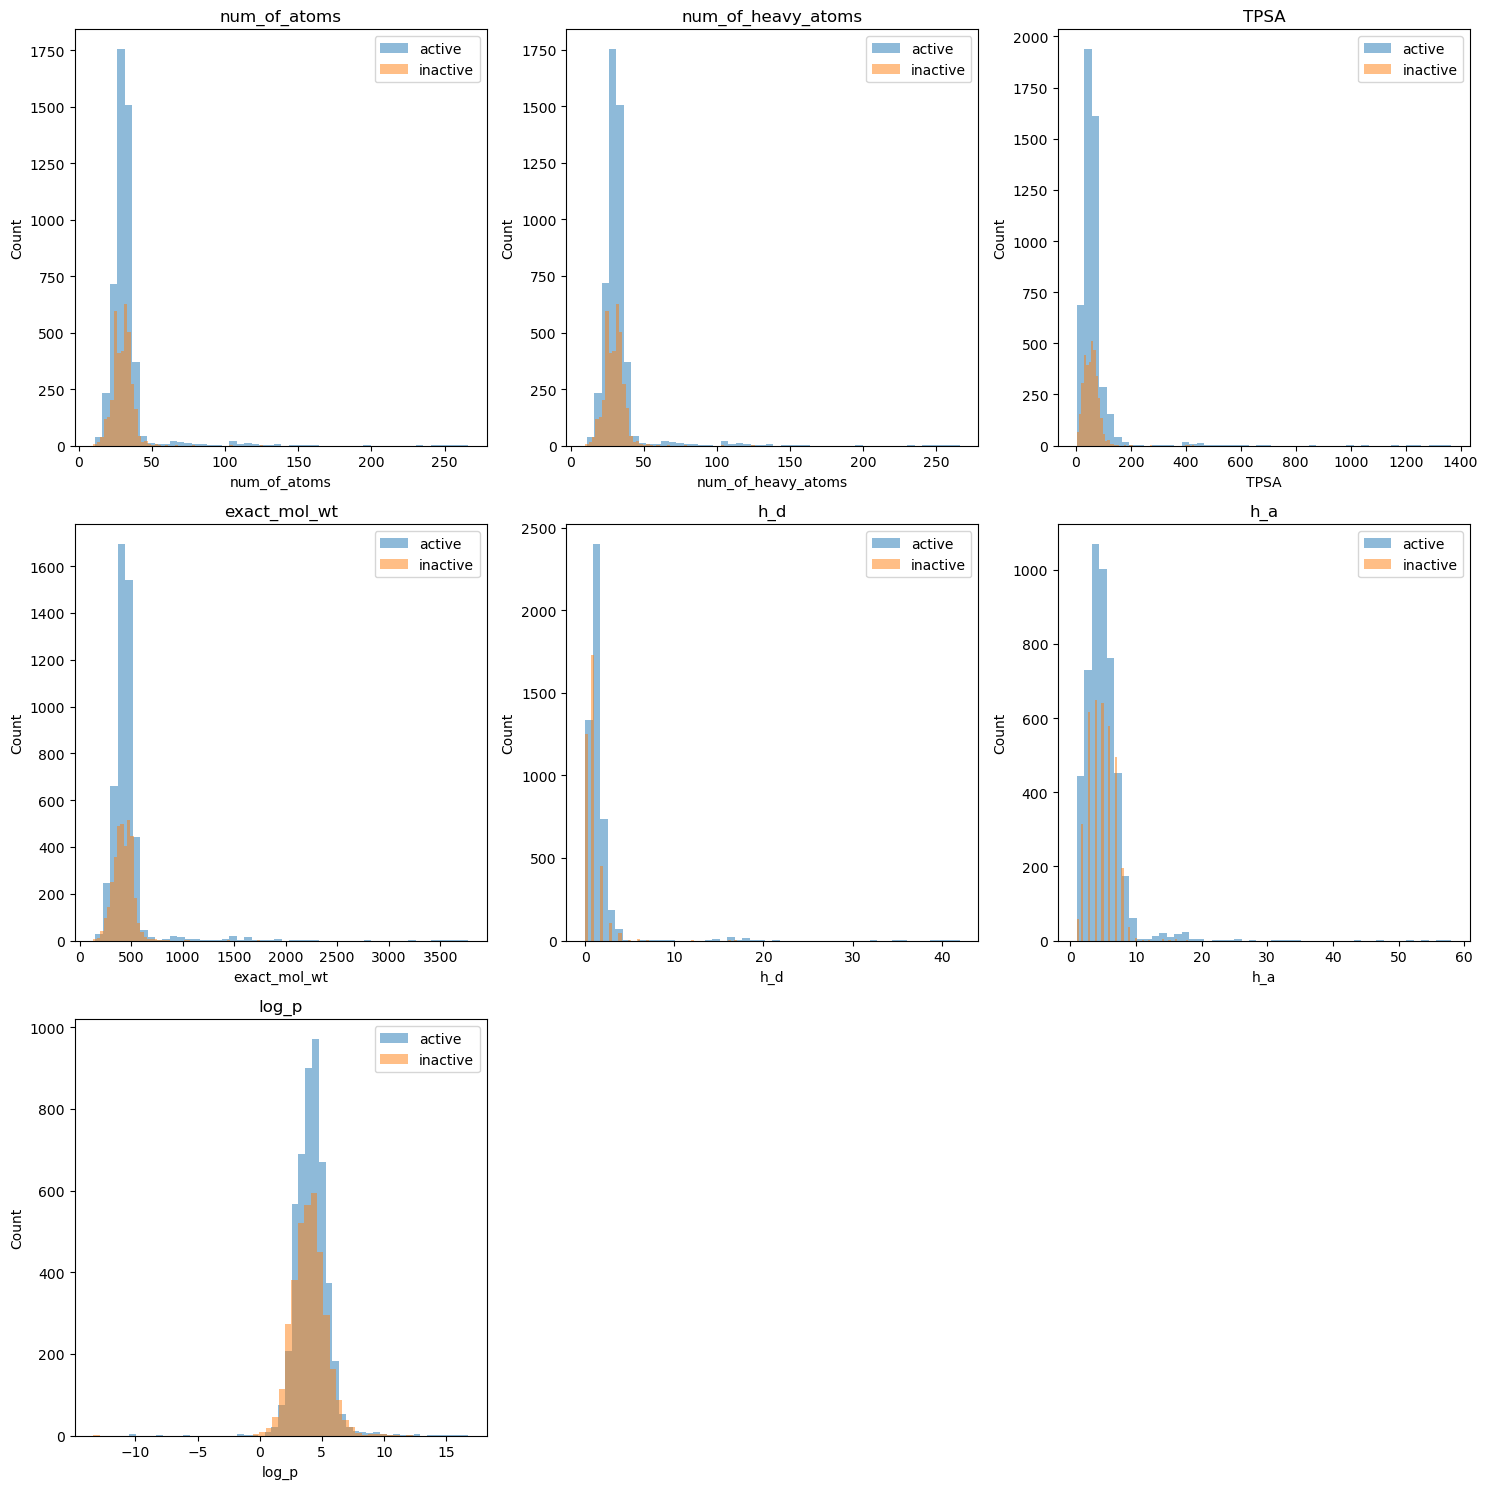

In [146]:
n = len(descriptors)
cols = 3
rows = (n + cols - 1) // cols

plt.figure(figsize=(15, 5 * rows))

for i, col in enumerate(descriptors, 1):
    plt.subplot(rows, cols, i)
    
    plt.hist(data[data["label"] == 1][col], bins=50, alpha=0.5, label="active")
    plt.hist(data[data["label"] == 0][col], bins=50, alpha=0.5, label="inactive")
    
    plt.title(col)
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.legend()

plt.tight_layout()
plt.show()

## Heatmapa korelacji

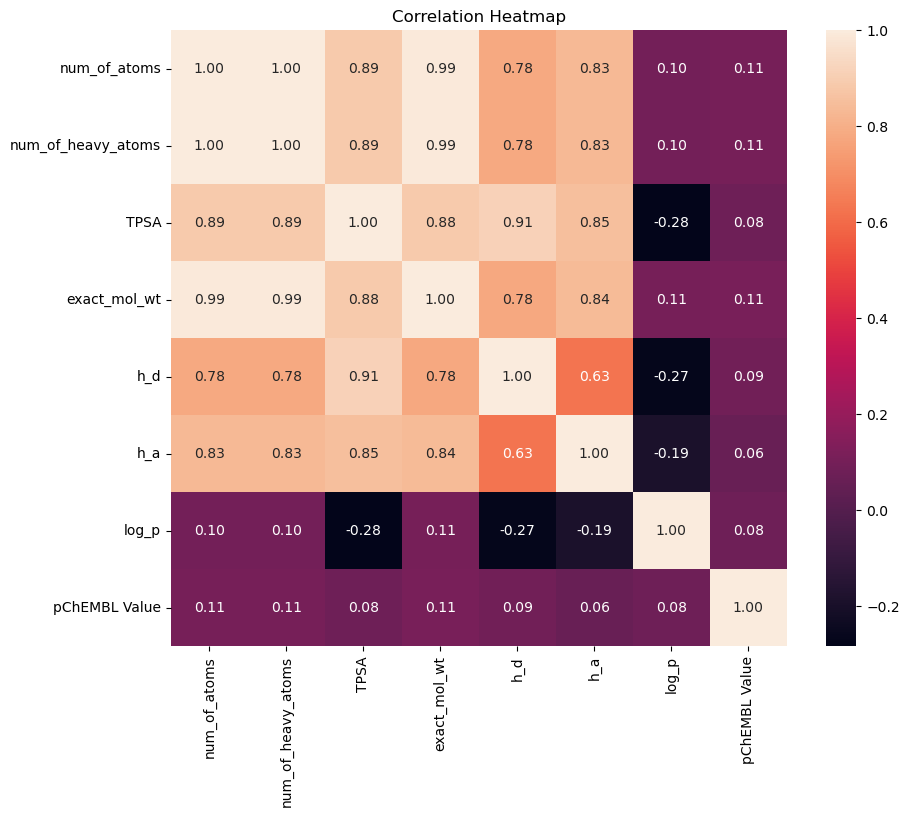

In [147]:
corr_heatmap = data[descriptors + ["pChEMBL Value"]].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_heatmap, annot=True, fmt=".2f", square=True)
plt.title("Correlation Heatmap")
plt.show()

## Violinplot active/inactive

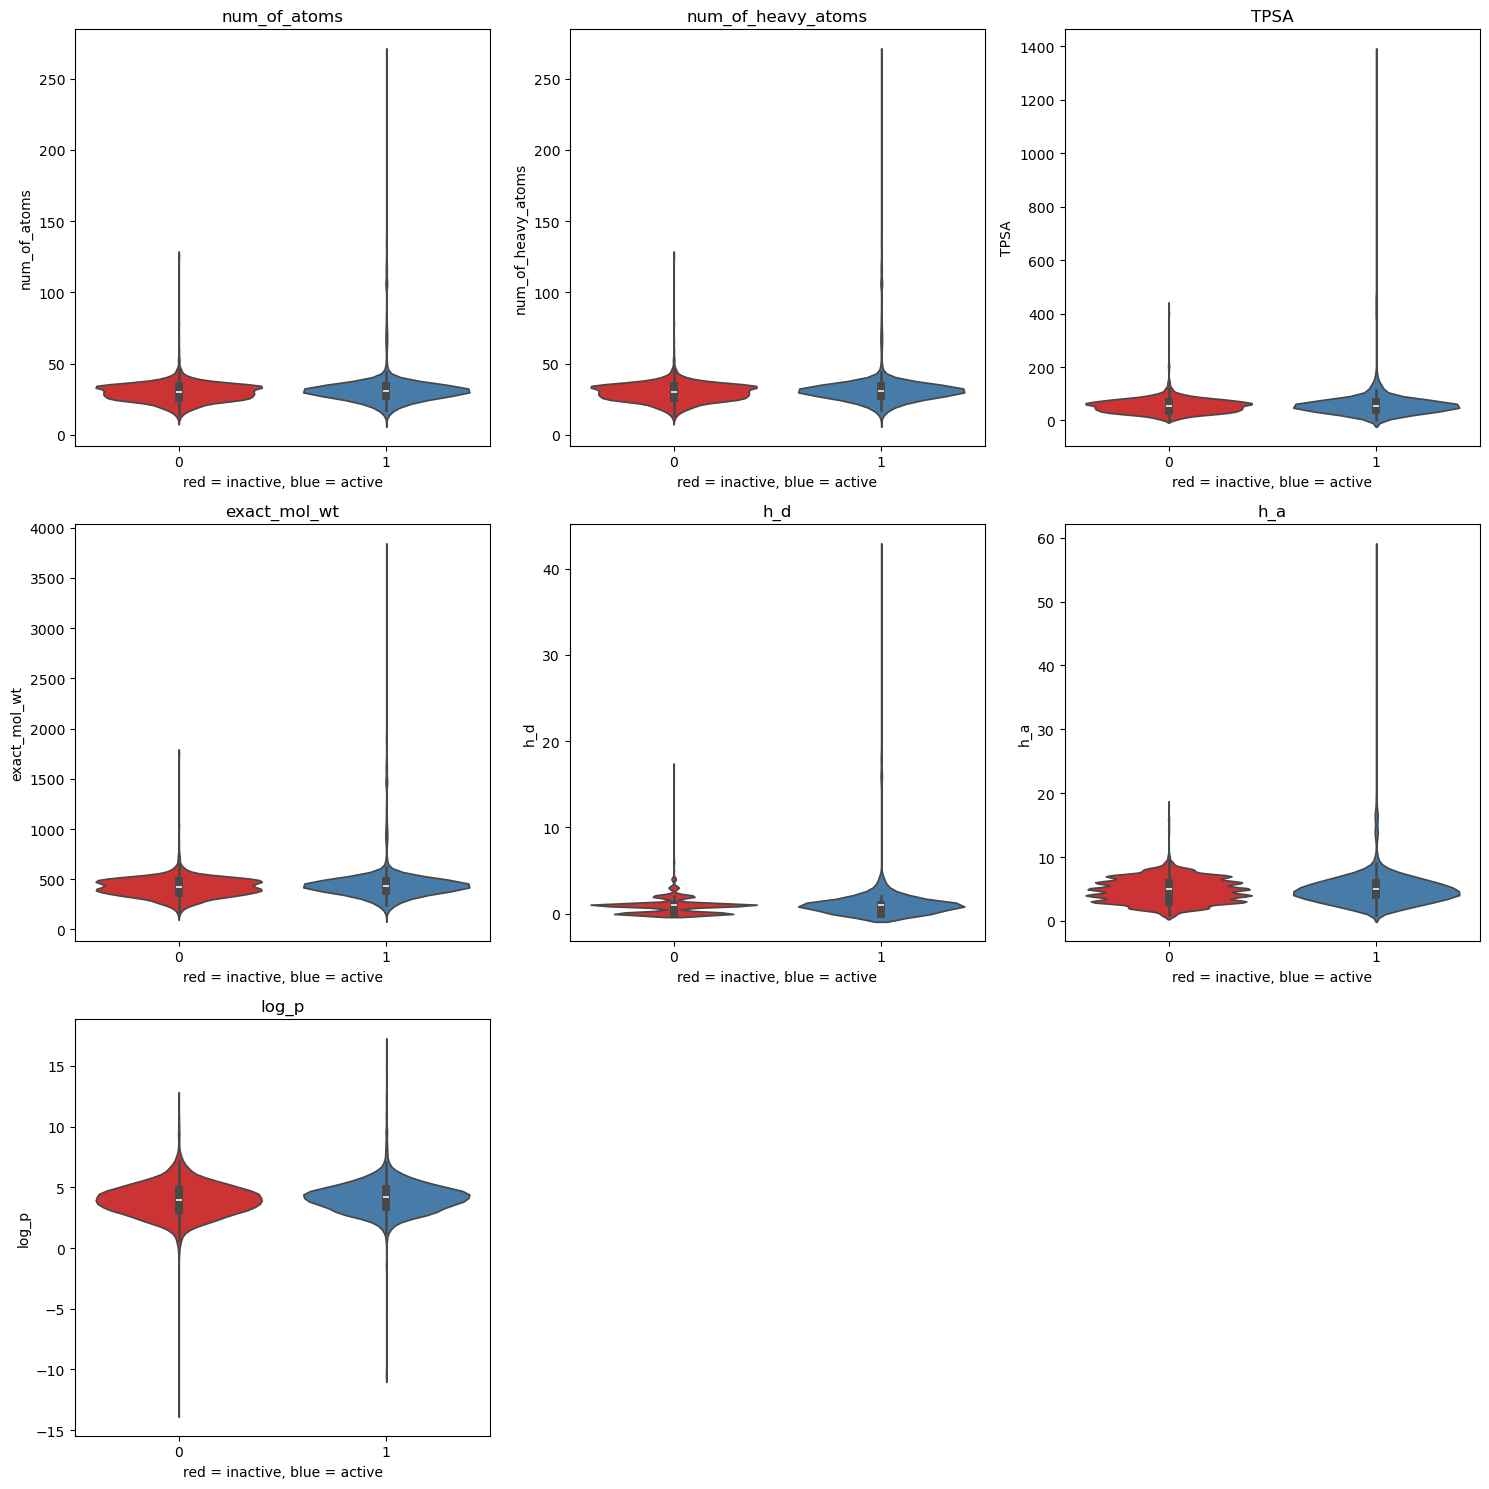

In [148]:
plt.figure(figsize=(15, 5 * rows))
for i, feature in enumerate(descriptors, 1):
    plt.subplot(rows, cols, i) 
    sns.violinplot(
        x="label",
        y=feature,
        data=data,
        hue="label",
        palette="Set1",
        legend=False
    )
    plt.title(feature)
    plt.xlabel("red = inactive, blue = active")
    plt.ylabel(feature)
plt.tight_layout()
plt.show()